# Imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# repo root on path
sys.path.insert(0, str(Path("..").resolve()))
from mvpfn import PFN, BarDistribution, train
from mvpfn.priors import regression_prior, gp_prior, gp_predict

In [2]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


# Configuration

In [3]:
SEQ_LEN = 24
BATCH = 48
STEPS = 10_000
LR = 3e-3

In [4]:
NUM_FEATURES = 1
NOISE = 0.05
Y_LOW, Y_HIGH = -6.0, 6.0
NUM_BARS = 100

# Regression

## Prior

In [5]:
get_batch_regression = regression_prior(SEQ_LEN, BATCH, NUM_FEATURES, NOISE)

x, y = get_batch_regression()
print("x", x.shape, "y", y.shape)

x torch.Size([24, 48, 1]) y torch.Size([24, 48])


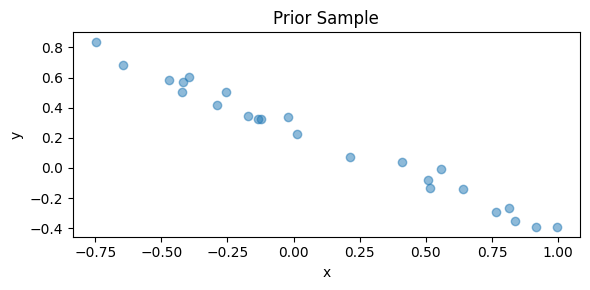

In [6]:
i = 0
plt.figure(figsize=(6, 3))
plt.scatter(x[:, i, 0], y[:, i], alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Prior Sample")
plt.tight_layout()
plt.show()

## Training

In [7]:
criterion_reg = BarDistribution(torch.linspace(Y_LOW, Y_HIGH, NUM_BARS + 1))

model_reg = PFN(
    num_features=NUM_FEATURES,
    n_out=criterion_reg.num_bars,
    d_model=64,
    nhead=4,
    dim_feedforward=128,
    num_layers=3,
)

model_reg = train(model_reg, criterion_reg, get_batch_regression, steps=STEPS, lr=LR, device=device, log_every=100)
model_reg = model_reg.eval()

/Users/noelkronenberg/Documents/GitHub/mv-pfn/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


step 100/10000 | loss -0.0452
step 200/10000 | loss -0.8199
step 300/10000 | loss -0.9278
step 400/10000 | loss -0.9809
step 500/10000 | loss -0.9515
step 600/10000 | loss -1.0494
step 700/10000 | loss -0.9586
step 800/10000 | loss -1.0266
step 900/10000 | loss -1.0481
step 1000/10000 | loss -1.0209
step 1100/10000 | loss -1.0522
step 1200/10000 | loss -1.0541
step 1300/10000 | loss -1.0491
step 1400/10000 | loss -1.0874
step 1500/10000 | loss -1.0383
step 1600/10000 | loss -1.1116
step 1700/10000 | loss -1.0677
step 1800/10000 | loss -1.1160
step 1900/10000 | loss -1.0869
step 2000/10000 | loss -1.1416
step 2100/10000 | loss -1.1218
step 2200/10000 | loss -1.0844
step 2300/10000 | loss -1.1292
step 2400/10000 | loss -1.1350
step 2500/10000 | loss -1.1223
step 2600/10000 | loss -1.0952
step 2700/10000 | loss -1.1170
step 2800/10000 | loss -1.1918
step 2900/10000 | loss -1.1618
step 3000/10000 | loss -1.1214
step 3100/10000 | loss -1.0898
step 3200/10000 | loss -1.1358
step 3300/10000 |

## Evaluation

In [8]:
with torch.no_grad():
    x, y = get_batch_regression() # new samples
    x, y = x.to(device), y.to(device)
    n_ctx = SEQ_LEN // 2 # context / query split

    logits = model_reg(x[:n_ctx], y[:n_ctx], x[n_ctx:])
    y_query = y[n_ctx:]
    
    pfn_mean = criterion_reg.mean(logits) # predicted mean
    pfn_qtile = criterion_reg.quantile(logits, center_prob=0.95) # 95% confidence band (as in paper)
    pfn_low, pfn_high = pfn_qtile[..., 0], pfn_qtile[..., 1] # lower / upper bounds
    
    mse = ((pfn_mean - y_query) ** 2).mean().item() # MSE
    print(f"MSE: {mse:.4f}")

MSE: 0.0032


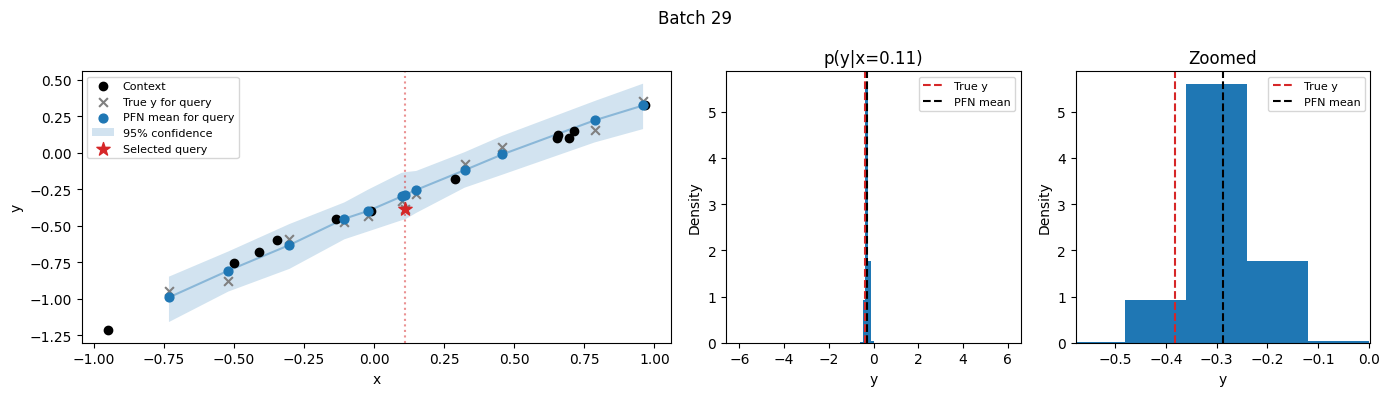

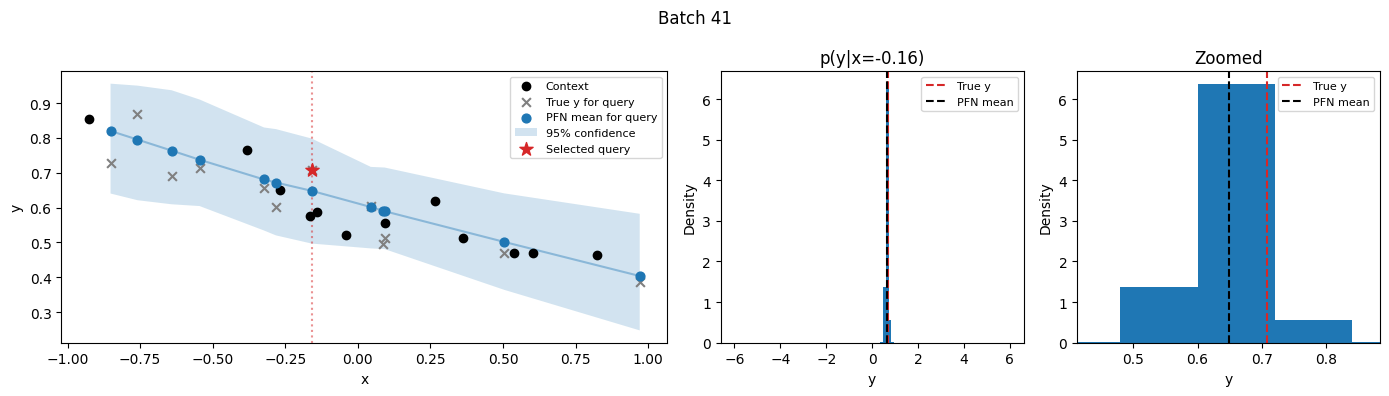

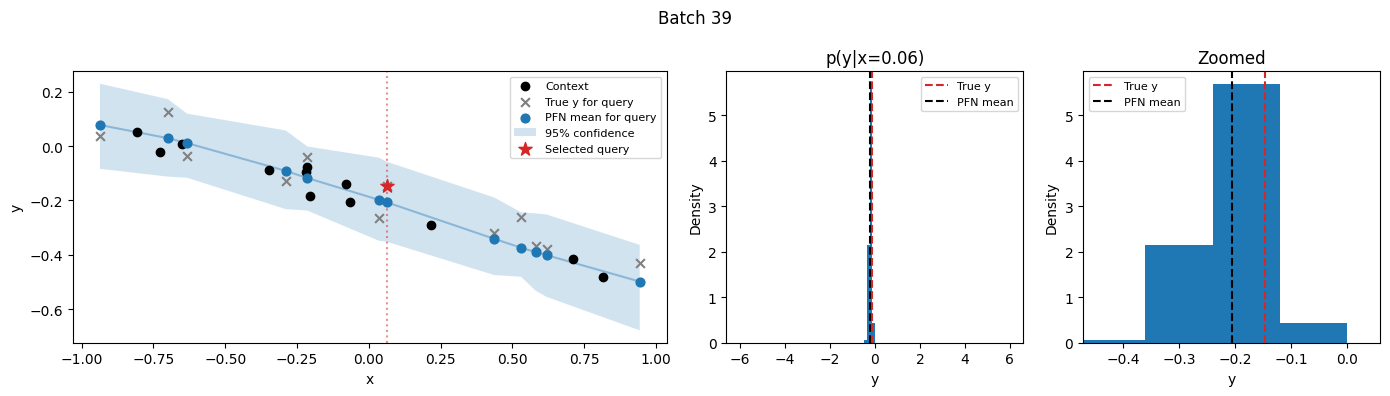

In [9]:
for batch_idx in torch.randperm(BATCH)[:3]:
    xc, yc = x[:n_ctx, batch_idx, 0].cpu(), y[:n_ctx, batch_idx].cpu() # context
    xq = x[n_ctx:, batch_idx, 0].cpu() # query
    yq = y[n_ctx:, batch_idx].cpu() # true y

    pfn = pfn_mean[:, batch_idx].cpu()
    low, high = pfn_low[:, batch_idx].cpu(), pfn_high[:, batch_idx].cpu() # quantile band
    order = xq.argsort() # sort for plotting

    qi = order[len(order) // 2] # middle query
    x_sel, y_true = xq[qi], yq[qi] # selected query and true y

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1, 1]})

    ax1.scatter(xc, yc, c="k", label="Context", zorder=3) # context
    ax1.scatter(xq, yq, c="gray", marker="x", s=40, label="True y for query", zorder=3) # true y
    ax1.scatter(xq, pfn, c="C0", s=40, label="PFN mean for query", zorder=4) # PFN mean
    
    ax1.plot(xq[order], pfn[order], c="C0", alpha=0.4) # PFN mean
    ax1.fill_between(xq[order], low[order], high[order], alpha=0.2, label="95% confidence") # confidence band (paper)

    ax1.scatter([x_sel], [y_true], c="C3", s=100, marker="*", zorder=5, label="Selected query") # selected query
    ax1.axvline(x_sel.item(), color="C3", ls=":", alpha=0.5) # vertical line
    
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend(fontsize=8)

    probs = torch.softmax(logits[qi, batch_idx], dim=-1).cpu() # bar probabilities
    borders = criterion_reg.borders.cpu() # bar borders
    widths = borders[1:] - borders[:-1] # bar widths
    density = probs / widths # bar density
    
    # full bar distribution
    ax2.bar(borders[:-1], density, width=widths, align="edge") # bar plot
    ax2.axvline(y_true.item(), color="C3", ls="--", label="True y") # true y
    ax2.axvline(pfn[qi].item(), color="k", ls="--", label="PFN mean") # PFN mean
    ax2.set_xlabel("y")
    ax2.set_ylabel("Density")
    ax2.set_title(f"p(y|x={x_sel:.2f})")
    ax2.legend(fontsize=8)

    # zoomed bar distribution
    centers = (borders[:-1] + borders[1:]) / 2 # bar centers
    dist_mean = (probs * centers).sum() # distribution mean
    dist_std = (probs * (centers - dist_mean) ** 2).sum().sqrt() # distribution std
    margin = max(4 * dist_std.item(), 0.15) # zoom margin
    ax3.bar(borders[:-1], density, width=widths, align="edge") # bar plot
    ax3.set_xlim(dist_mean - margin, dist_mean + margin) # zoom
    ax3.axvline(y_true.item(), color="C3", ls="--", label="True y") # true y
    ax3.axvline(pfn[qi].item(), color="k", ls="--", label="PFN mean") # PFN mean
    ax3.set_xlabel("y")
    ax3.set_ylabel("Density")
    ax3.set_title("Zoomed")
    ax3.legend(fontsize=8)

    fig.suptitle(f"Batch {batch_idx}")
    plt.tight_layout()
    plt.show()

# Gaussian Process

## Prior

In [10]:
GP_LENGTHSCALE = 0.5 # RBF kernel length scale (shared by the prior and the GP reference)

get_batch_gp = gp_prior(SEQ_LEN, BATCH, NUM_FEATURES, NOISE, lengthscale=GP_LENGTHSCALE)

x, y = get_batch_gp()
print("x", x.shape, "y", y.shape)

x torch.Size([24, 48, 1]) y torch.Size([24, 48])


/Users/noelkronenberg/Documents/GitHub/mv-pfn/.venv/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


## Training

In [11]:
model_gp = PFN(
    num_features=NUM_FEATURES,
    n_out=criterion_reg.num_bars,
    d_model=64,
    nhead=4,
    dim_feedforward=128,
    num_layers=3,
)

model_gp = train(model_gp, criterion_reg, get_batch_gp, steps=STEPS, lr=LR, device=device, log_every=100)
model_gp = model_gp.eval()

/Users/noelkronenberg/Documents/GitHub/mv-pfn/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/Users/noelkronenberg/Documents/GitHub/mv-pfn/mvpfn/bar_distribution.py:84: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  idx = torch.searchsorted(self.borders, y) - 1 # index of the bucket that contains the target


step 100/10000 | loss 0.7761
step 200/10000 | loss 0.1196
step 300/10000 | loss -0.2059
step 400/10000 | loss -0.3095
step 500/10000 | loss -0.4539
step 600/10000 | loss -0.3674
step 700/10000 | loss -0.4144
step 800/10000 | loss -0.3402
step 900/10000 | loss -0.4663
step 1000/10000 | loss -0.3525
step 1100/10000 | loss -0.4127
step 1200/10000 | loss -0.5032
step 1300/10000 | loss -0.4753
step 1400/10000 | loss -0.6043
step 1500/10000 | loss -0.5144
step 1600/10000 | loss -0.5088
step 1700/10000 | loss -0.4793
step 1800/10000 | loss -0.5083
step 1900/10000 | loss -0.6037
step 2000/10000 | loss -0.5782
step 2100/10000 | loss -0.5072
step 2200/10000 | loss -0.5307
step 2300/10000 | loss -0.4608
step 2400/10000 | loss -0.5766
step 2500/10000 | loss -0.4886
step 2600/10000 | loss -0.5311
step 2700/10000 | loss -0.5599
step 2800/10000 | loss -0.6158
step 2900/10000 | loss -0.5664
step 3000/10000 | loss -0.5199
step 3100/10000 | loss -0.5548
step 3200/10000 | loss -0.5656
step 3300/10000 | l

In [12]:
with torch.no_grad():
    xc = torch.tensor([-0.5, 0.5]) # example inputs (2 points, as in Müller et al., 2021)
    yc = torch.tensor([1.0, 0.7]) # example outputs
    xs = torch.linspace(-1, 1, 500) # dense query grid

    # PFN
    logits = model_gp(xc[:, None, None].to(device), yc[:, None].to(device), xs[:, None, None].to(device))
    probs = torch.softmax(logits[:, 0], dim=-1).cpu() # bucket probabilities
    borders = criterion_reg.borders.cpu()
    density = (probs / (borders[1:] - borders[:-1])).T # density for the heatmap

    pfn_mean = criterion_reg.mean(logits)[:, 0].cpu() # PFN mean
    pfn_low, pfn_high = criterion_reg.quantile(logits, center_prob=0.95)[:, 0].cpu().unbind(-1) # PFN 95% confidence band (as in paper)

    # exact GP
    gp_mean, gp_std = gp_predict(xc, yc, xs, lengthscale=GP_LENGTHSCALE, noise=NOISE) # exact GP posterior
    gp_low, gp_high = gp_mean - 1.96 * gp_std, gp_mean + 1.96 * gp_std # exact GP 95% confidence band

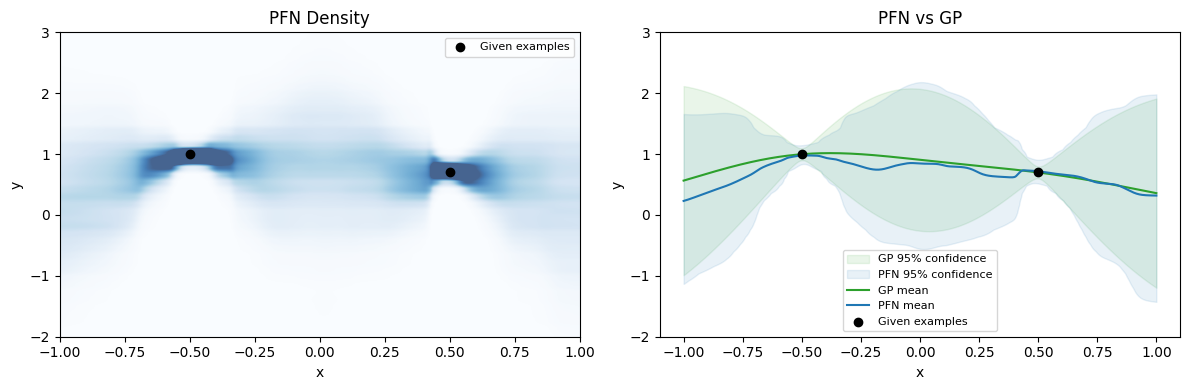

In [13]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4))

# PFN predictive density [Müller et al., 2021, Figure 3a]
ax_a.imshow(density, origin="lower", aspect="auto", extent=[-1, 1, Y_LOW, Y_HIGH], cmap="Blues", vmax=density.quantile(0.995), alpha=0.75) # PFN density
ax_a.scatter(xc, yc, c="k", zorder=3, label="Given examples") # context points
ax_a.set(xlabel="x", ylabel="y", title="PFN Density", ylim=(-2, 3))
ax_a.legend(fontsize=8)

# PFN vs GP [Müller et al., 2021, Figure 3b]
ax_b.fill_between(xs, gp_low, gp_high, color="C2", alpha=0.1, label="GP 95% confidence") # GP band
ax_b.fill_between(xs, pfn_low, pfn_high, color="C0", alpha=0.1, label="PFN 95% confidence") # PFN band
ax_b.plot(xs, gp_mean, c="C2", label="GP mean") # GP mean
ax_b.plot(xs, pfn_mean, c="C0", label="PFN mean") # PFN mean
ax_b.scatter(xc, yc, c="k", zorder=3, label="Given examples") # context points
ax_b.set(xlabel="x", ylabel="y", title="PFN vs GP", ylim=(-2, 3))
ax_b.legend(fontsize=8)

plt.tight_layout()
plt.show()